# Monte Carlo Value-at-Risk (VaR)

This notebook demonstrates the use of Monte Carlo Simulation to estimate portfolio Value-at-Risk (VaR).

Monte Carlo methods generate many simulated paths of portfolio returns, based on the estimated mean vector and covariance matrix from historical data. The chosen quantile of the simulated return distribution (the 5th percentile for 95% confidence) is taken as the VaR estimate over the specified horizon.

The inclusion of covariance is essential, since asset returns can be strongly correlated.

Included:
1. Load a multi-asset portfolio
2. Estimate returns and covariance
3. Run Monte Carlo simulation
4. Compute Monte Carlo VaR
5. Visualize the simulated return distribution

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from src.var_methods import monte_carlo_var

## Load Data

Using a portfolio of 4 assets: SPY, BND, GLD, and QQQ

In [3]:
tickers = ["SPY", "BND", "GLD", "QQQ"]
data = pd.read_csv(
    "../data/sample_prices.csv",
    index_col=0,
    parse_dates=[0],
    date_parser=lambda x: pd.to_datetime(x, format="%d/%m/%Y")
)
log_returns = np.log(data / data.shift(1)).dropna()

log_returns.head()

,BND,GLD,QQQ,SPY
Date,,,,
2020-01-03,0.003566,0.013181,-0.009202,-0.007601
2020-01-06,-0.001187,0.010435,0.006423,0.003808
2020-01-07,-0.000832,0.003927,-0.000139,-0.002816
2020-01-08,-0.001547,-0.007530,0.007488,0.005315
2020-01-09,0.001190,-0.005668,0.008438,0.006758


## Monte Carlo VaR

- Assuming equal portfolio weights and simulating 10,000 paths over a 5-day horizon
- The Monte Carlo script is vectorised, drastically improving efficiency
- All random perturbations are calculated in one step using numpy arrays 

In [4]:
weights = np.array([0.25, 0.25, 0.25, 0.25])
portfolio_value = 1_000_000
alpha = 0.05

mc_var = monte_carlo_var(
    returns=log_returns,
    weights=weights,
    alpha=alpha,
    horizon=5,
    sims=10000,
    portfolio_value=portfolio_value,
    seed=42
)

print("Monte Carlo 95% 5-day VaR: " + "$" + str(int(mc_var)))

Monte Carlo 95% 5-day VaR: $29671


## Visualize Simulated Distribution

Plotting the histogram of simulated 5-day returns with the 95% VaR cutoff.

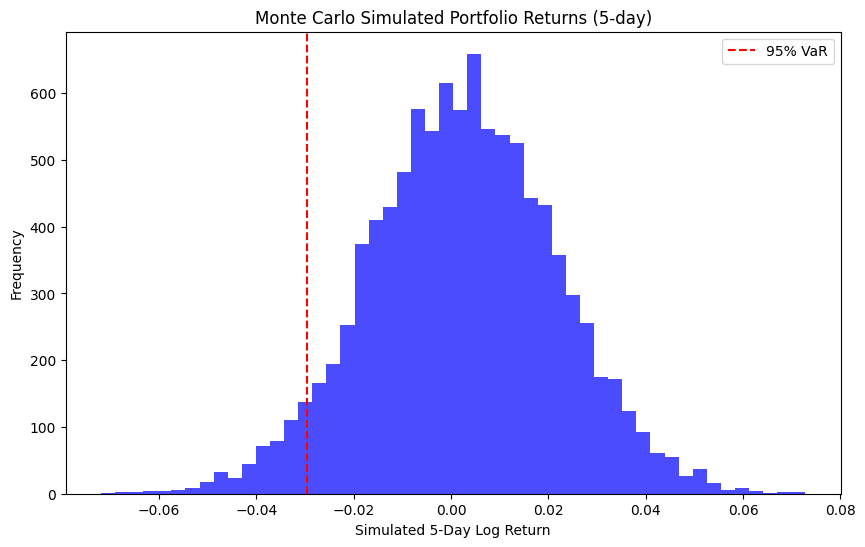

In [6]:
mu = log_returns.mean().values
cov = log_returns.cov().values

simulated_paths = np.random.multivariate_normal(mu, cov, size=(10000, 5))
simulated_weighted = simulated_paths @ weights
simulated_total = simulated_weighted.sum(axis=1)

plt.figure(figsize=(10,6))
plt.hist(simulated_total, bins=50, alpha=0.7, color="blue")
plt.axvline(-mc_var/portfolio_value, color="red", linestyle="--", label="95% VaR")
plt.title("Monte Carlo Simulated Portfolio Returns (5-day)")
plt.xlabel("Simulated 5-Day Log Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Summary

- Monte Carlo VaR uses simulations of portfolio returns to estimate risk.
- This approach can incorporate correlations, fat tails (with alternative distributions), and complex portfolios.
- Much more flexible than Historical or Parametric VaR, but computationally more expensive.
